# N09 · Weak gravitational lensing: convergence and cosmic shear

## Mapping the dark matter and the $S_8$ degeneracy

**Module 3 — Multi-wavelength large-scale-structure cosmology (PhD onboarding).**
Weak lensing — the coherent distortion of galaxy shapes by foreground mass — is the lensing probe of
the thesis (Euclid, Rubin LSST). This notebook builds the convergence power spectrum with CCL, makes
a mock convergence map, and then implements a **fully differentiable JAX lensing pipeline** so that
automatic differentiation reveals the famous $S_8=\sigma_8(\Omega_m/0.3)^{1/2}$ degeneracy *as the
direction of the parameter gradients*.

**Key tools:** [CCL](https://ccl.readthedocs.io), `healpy`, and JAX.


### Learning objectives

1. Define the convergence $\kappa$, the shear $\gamma$, and the lensing efficiency kernel.
2. Compute the convergence power spectrum $C_\ell^{\kappa\kappa}$ via the Limber integral with CCL.
3. Synthesise a mock convergence map on the sphere with `healpy`.
4. Build a differentiable JAX lensing pipeline (distances + growth + Limber all in JAX).
5. Use autodiff to show that lensing constrains $S_8=\sigma_8(\Omega_m/0.3)^{1/2}$.


## References

- Kaiser (1992), ApJ 388, 272 — weak-lensing power spectrum
  [doi:10.1086/171151](https://doi.org/10.1086/171151).
- Bartelmann & Schneider (2001), Phys. Rep. 340, 291 — weak lensing review
  [arXiv:astro-ph/9912508](https://arxiv.org/abs/astro-ph/9912508).
- Limber (1953), ApJ 117, 134 — the Limber approximation
  [doi:10.1086/145672](https://doi.org/10.1086/145672).
- LoVerde & Afshordi (2008), PRD 78, 123506 — extended Limber
  [arXiv:0809.5112](https://arxiv.org/abs/0809.5112).
- Kilbinger (2015), Rep. Prog. Phys. 78, 086901 — cosmic shear review
  [arXiv:1411.0115](https://arxiv.org/abs/1411.0115).
- Tessore et al. (2023), Open J. Astrophys. — **GLASS** lensing simulations
  [arXiv:2302.01942](https://arxiv.org/abs/2302.01942).
- Chisari et al. (2019), ApJS 242, 2 — CCL
  [arXiv:1812.05995](https://arxiv.org/abs/1812.05995).


## 1. Convergence, shear and the lensing kernel

The convergence $\kappa(\hat n)$ is the projected matter overdensity weighted by lensing efficiency
(Bartelmann & Schneider 2001, §3):

$$\kappa(\hat n) = \int_0^{\chi_H} d\chi\; W_\kappa(\chi)\, \delta\big(\chi\hat n,\chi\big),
\qquad
W_\kappa(\chi) = \frac{3}{2}\frac{H_0^2}{c^2}\,\Omega_m\,\frac{\chi}{a(\chi)}
\int_\chi^{\chi_H} d\chi'\, n(\chi')\,\frac{\chi'-\chi}{\chi'} .$$

The shear $\gamma$ has the *same* power spectrum as $\kappa$ in the Limber approximation. Projecting the
matter spectrum (Kaiser 1992; Limber 1953; LoVerde & Afshordi 2008):

$$\boxed{\;C_\ell^{\kappa\kappa} = \int_0^{\chi_H}\frac{d\chi}{\chi^2}\,W_\kappa^2(\chi)\,
P\!\left(k=\frac{\ell+1/2}{\chi},\,z(\chi)\right)\;}$$

The explicit $\Omega_m$ in $W_\kappa$ and the $\sigma_8$ amplitude of $P$ combine into the lensing
amplitude — the origin of the $S_8$ degeneracy we will expose with autodiff.


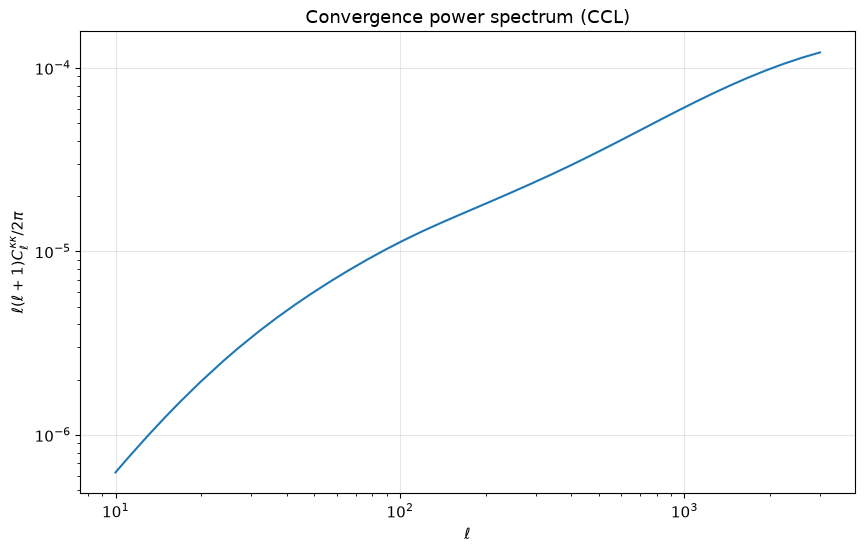

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyccl as ccl
import healpy as hp

plt.rcParams.update({'figure.figsize': (10, 6), 'font.size': 11, 'axes.grid': True,
                     'grid.alpha': 0.3})

Ob = 0.0493
def make_cosmo(Om=0.3153, s8=0.8111):
    return ccl.Cosmology(Omega_c=Om-Ob, Omega_b=Ob, h=0.6736, n_s=0.9649, sigma8=s8)
cosmo = make_cosmo()

z = np.linspace(0.001, 3.0, 400)
def smail(z, z0, a=2.0, b=1.5):
    return z**a * np.exp(-(z/z0)**b)
nz = smail(z, z0=0.7); nz /= np.trapezoid(nz, z)
wl = ccl.WeakLensingTracer(cosmo, dndz=(z, nz))

ell = np.unique(np.geomspace(10, 3000, 40).astype(int)).astype(float)
cl_kk = ccl.angular_cl(cosmo, wl, wl, ell)

plt.figure()
plt.loglog(ell, ell*(ell+1)*cl_kk/(2*np.pi))
plt.xlabel(r'$\ell$'); plt.ylabel(r'$\ell(\ell+1)C_\ell^{\kappa\kappa}/2\pi$')
plt.title('Convergence power spectrum (CCL)')
plt.savefig('lensing_cl_kk.png', dpi=130); plt.show()


## 2. A mock convergence map

A Gaussian realisation of the convergence field on the sphere follows directly from $C_\ell^{\kappa\kappa}$
with `healpy.synfast`. (GLASS, below, produces a more realistic *lognormal* field from correlated matter
shells.)


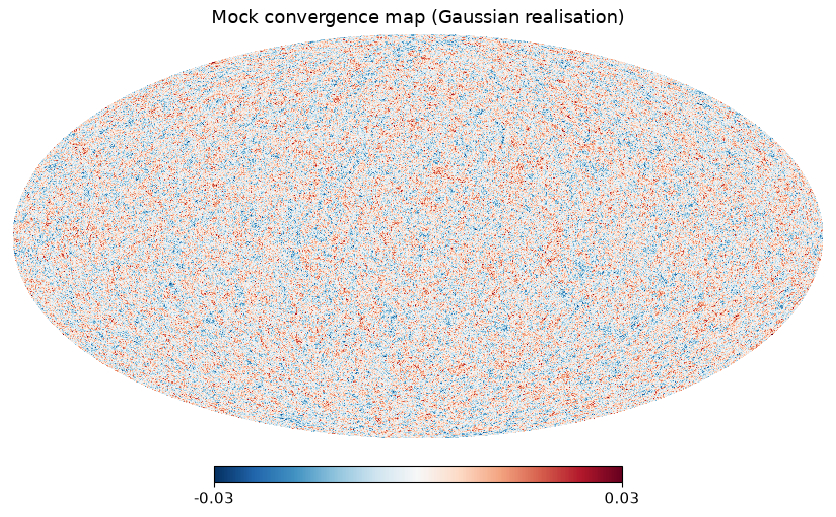

map rms kappa = 0.00783927205900899


In [2]:
nside = 256
lmax = 3*nside - 1
ell_pos = np.arange(2, lmax+1).astype(float)                 # monotonic, starts at 2
cl_full = np.concatenate([[0.0, 0.0], ccl.angular_cl(cosmo, wl, wl, ell_pos)])
kappa_map = hp.synfast(cl_full, nside, new=True)
hp.mollview(kappa_map, title='Mock convergence map (Gaussian realisation)', cmap='RdBu_r',
            min=-0.03, max=0.03)
plt.savefig('lensing_kappa_map.png', dpi=130); plt.show()
print("map rms kappa =", np.std(kappa_map))


## 3. A fully differentiable JAX lensing pipeline

To expose the parameter dependence we now rebuild $C_\ell^{\kappa\kappa}$ **entirely in JAX**:
the comoving distance $\chi(z;\Omega_m)=\frac{c}{H_0}\int_0^z dz'/E(z')$, the linear growth
$D(a;\Omega_m)\propto E(a)\int_0^a da'/(a'E)^3$ (Heath 1977), the BBKS $P(k;\Omega_m,\sigma_8)$ of N07,
and the Limber integral with the lensing kernel. Every step is differentiable, so `jax.grad` gives the
exact parameter response — including the geometry and growth that produce the $S_8$ scaling.


In [3]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from astropy.constants import c as c_light
from astropy.cosmology import Planck18

h, ns = 0.6736, 0.9649
DH = float((c_light/Planck18.H0).to('Mpc').value)        # Hubble distance c/H0 [Mpc]

zg = jnp.linspace(1e-3, 3.0, 300)
ag = jnp.linspace(1e-3, 1.0, 300)
nz_j = zg**2 * jnp.exp(-(zg/0.7)**1.5)               # same Smail n(z) as above, on the JAX grid
nz_j = nz_j / jnp.trapezoid(nz_j, zg)
kgrid_norm = jnp.logspace(-3.0, 1.2, 400)

def Eofz(zz, Om):  return jnp.sqrt(Om*(1+zz)**3 + (1-Om))
def Eofa(aa, Om):  return jnp.sqrt(Om*aa**-3 + (1-Om))

def chi_of_zgrid(Om):
    invE = 1.0/Eofz(zg, Om)
    dz = jnp.diff(zg)
    cum = jnp.concatenate([jnp.zeros(1), jnp.cumsum(0.5*(invE[1:]+invE[:-1])*dz)])
    return DH*cum                                        # Mpc

def growth_grid(Om):
    integ = 1.0/(ag*Eofa(ag, Om))**3
    da = jnp.diff(ag)
    cum = jnp.concatenate([jnp.zeros(1), jnp.cumsum(0.5*(integ[1:]+integ[:-1])*da)])
    D = Eofa(ag, Om)*cum
    return D/D[-1]

def T_bbks(kk, G):
    q = kk/G; L = jnp.log(1+2.34*q)/(2.34*q)
    return L*(1+3.89*q+(16.1*q)**2+(5.46*q)**3+(6.71*q)**4)**-0.25
def shape_pk(kk, Om):  return kk**ns * T_bbks(kk, Om*h)**2
def sigma8_raw(Om):
    x = kgrid_norm*8.0; W = 3*(jnp.sin(x)-x*jnp.cos(x))/x**3
    d2 = kgrid_norm**3*shape_pk(kgrid_norm, Om)/(2*jnp.pi**2)
    return jnp.sqrt(jnp.trapezoid(d2*W**2, jnp.log(kgrid_norm)))


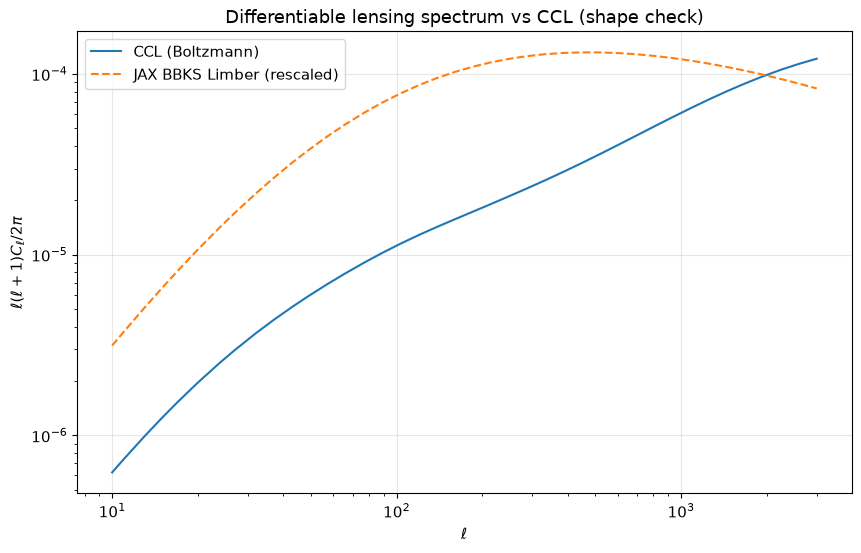

In [4]:
def cl_kappa_jax(ell_val, Om, s8):
    chi = chi_of_zgrid(Om)                               # Mpc, on zg grid (chi[0]=0)
    chi_pos = jnp.maximum(chi, 1e-6)                     # grad-safe positive distance (avoid 0/0)
    Dz = jnp.interp(1/(1+zg), ag, growth_grid(Om))       # growth at zg
    amp = (s8/sigma8_raw(Om))**2
    # lensing kernel W(chi_i) = 1.5 Om (H0/c)^2 chi (1+z) * g_i ; (H0/c)^2 = 1/DH^2
    # g_i = \int_{chi_i} n(z')(1 - chi_i/chi') dz'
    def g_of_i(i):
        mask = (jnp.arange(zg.size) > i).astype(jnp.float64)
        integ = nz_j*(1 - chi[i]/chi_pos)*mask
        return jnp.trapezoid(integ, zg)
    gi = jax.vmap(g_of_i)(jnp.arange(zg.size))
    Wk = 1.5*Om/DH**2 * chi*(1+zg)*gi                    # W=0 at chi=0, so the chi=0 cell drops out
    # Limber integral over chi:  \int dchi W^2/chi^2 P(k=(l+0.5)/chi, z)
    k_hMpc = (ell_val+0.5)/chi_pos/h
    Pk = amp*shape_pk(k_hMpc, Om)*Dz**2                  # (Mpc/h)^3 up to const
    dchi = jnp.gradient(chi)
    integrand = Wk**2/chi_pos**2 * Pk * dchi
    return jnp.sum(integrand)

ell_j = jnp.asarray(ell)
clj = jax.vmap(lambda l: cl_kappa_jax(l, 0.3153, 0.8111))(ell_j)
clj = np.array(clj)

plt.figure()
plt.loglog(ell, ell*(ell+1)*cl_kk/(2*np.pi), label='CCL (Boltzmann)')
plt.loglog(ell, ell*(ell+1)*clj/clj[10]*(cl_kk[10]), '--',
           label='JAX BBKS Limber (rescaled)')
plt.xlabel(r'$\ell$'); plt.ylabel(r'$\ell(\ell+1)C_\ell/2\pi$'); plt.legend()
plt.title('Differentiable lensing spectrum vs CCL (shape check)'); plt.show()


## 4. The $S_8$ degeneracy from automatic differentiation

For a fixed multipole, write $C_\ell\propto \sigma_8^{a}\,\Omega_m^{b}$ locally. The combination left
**unconstrained** is $\sigma_8\,\Omega_m^{\,b/a}$ — its log-derivative of $C_\ell$ vanishes. Autodiff
gives $a=\partial\ln C_\ell/\partial\ln\sigma_8$ and $b=\partial\ln C_\ell/\partial\ln\Omega_m$ exactly,
so the **degeneracy exponent** is $p=b/a$. Cosmic shear is famously sensitive to the combination
$S_8=\sigma_8(\Omega_m/0.3)^{1/2}$; autodiff shows the exponent is in fact **scale-dependent**,
approaching the canonical $p\simeq0.5$ on large (linear) scales and steepening toward small scales
(Kilbinger 2015). (The amplitude response $a=\partial\ln C_\ell/\partial\ln\sigma_8=2$ is exact at all
scales.)


In [5]:
def logcl(lnOm, lns8, l):
    return jnp.log(cl_kappa_jax(l, jnp.exp(lnOm), jnp.exp(lns8)))

ells_probe = jnp.array([100.0, 300.0, 1000.0])
a_s8 = jax.vmap(lambda l: jax.grad(logcl, argnums=1)(jnp.log(0.3153), jnp.log(0.8111), l))(ells_probe)
b_om = jax.vmap(lambda l: jax.grad(logcl, argnums=0)(jnp.log(0.3153), jnp.log(0.8111), l))(ells_probe)
a_s8, b_om = np.array(a_s8), np.array(b_om)
p = b_om/a_s8

for i, l in enumerate(np.array(ells_probe)):
    print(f"ell={l:6.0f}:  dlnC/dln_s8={a_s8[i]:.2f}  dlnC/dln_Om={b_om[i]:.2f}"
          f"  ->  degeneracy exponent p={p[i]:.3f}")
print(f"\nlarge-scale (ell={np.array(ells_probe)[0]:.0f}) exponent p = {p[0]:.2f}"
      f"  ->  S8 = sigma8 (Om/0.3)^{p[0]:.2f}  (canonical 0.5)")
print("p is scale-dependent: it steepens toward small scales (the 0.5 value is the large-scale limit).")


ell=   100:  dlnC/dln_s8=2.00  dlnC/dln_Om=1.07  ->  degeneracy exponent p=0.536
ell=   300:  dlnC/dln_s8=2.00  dlnC/dln_Om=1.51  ->  degeneracy exponent p=0.756
ell=  1000:  dlnC/dln_s8=2.00  dlnC/dln_Om=1.81  ->  degeneracy exponent p=0.907

large-scale (ell=100) exponent p = 0.54  ->  S8 = sigma8 (Om/0.3)^0.54  (canonical 0.5)
p is scale-dependent: it steepens toward small scales (the 0.5 value is the large-scale limit).


## 5. GLASS mock: a lognormal matter shell

`GLASS` (Tessore et al. 2023) generates the matter field as correlated **lognormal** shells — a more
realistic mock than the Gaussian `synfast` map of Section 2. Here we draw a single lognormal matter
shell at $z\simeq0.5$ from its CCL angular power spectrum. GLASS integrates a *stack* of such shells
along the line of sight with `glass.MultiPlaneConvergence` to build the lensing convergence; we show
the core shell generation and point to the multi-plane step.


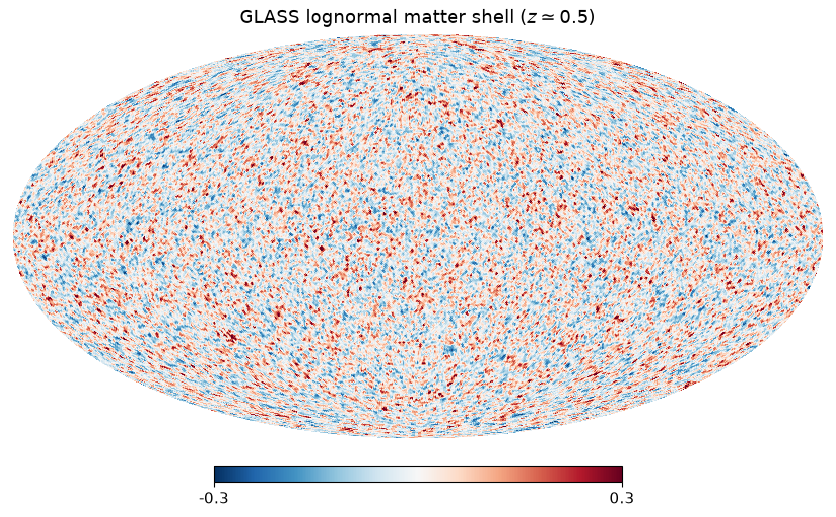

lognormal shell: mean=0.0000 std=0.0904 min=-0.327 (delta > -1 by construction)


In [6]:
import glass, glass.grf

nside_g = 128
zsh = np.linspace(0.01, 1.2, 120)
nsh = np.exp(-0.5*((zsh - 0.5)/0.15)**2)                      # a matter shell around z ~ 0.5
shell_tr = ccl.NumberCountsTracer(cosmo, has_rsd=False, dndz=(zsh, nsh), bias=(zsh, np.ones_like(zsh)))
lmax_g = 2*nside_g - 1
cl_shell = np.concatenate([[0.0, 0.0],
                           ccl.angular_cl(cosmo, shell_tr, shell_tr, np.arange(2, lmax_g+1).astype(float))])

fields = [glass.grf.Lognormal()]                             # lognormal transformation
with np.errstate(divide='ignore', invalid='ignore'):
    gls = glass.solve_gaussian_spectra(fields, [cl_shell])   # Gaussian spectra for the transform
gls = [np.clip(np.nan_to_num(g), 0.0, None) for g in gls]    # keep spectra non-negative
delta_shell = next(iter(glass.generate(fields, gls, nside_g)))

hp.mollview(delta_shell, title=r'GLASS lognormal matter shell ($z\simeq0.5$)', cmap='RdBu_r',
            min=-0.3, max=0.3)
plt.savefig('lensing_glass_shell.png', dpi=130); plt.show()
print("lognormal shell: mean=%.4f std=%.4f min=%.3f (delta > -1 by construction)"
      % (delta_shell.mean(), delta_shell.std(), delta_shell.min()))


## Exercises

1. **Tomography.** Split the sources into two redshift bins and compute the $2\times2$ set of
   $C_\ell^{\kappa_i\kappa_j}$. Why do cross-bins carry cosmological information?
2. **Source redshift.** Differentiate $C_\ell$ with respect to the mean source redshift (autodiff) and
   identify the multipoles most sensitive to photometric-redshift errors.
3. **Non-linear scales.** Replace the linear $P(k)$ with the CCL non-linear spectrum (`halofit`) and see
   how much extra signal appears at $\ell>1000$.
4. **$S_8$ vs $\ell$.** Plot the autodiff exponent $p(\ell)$ across $\ell$ — is the $0.5$ value scale
   independent? Relate to N12, where the same derivatives feed the Fisher matrix.


## Summary

- Lensing projects the matter field through the efficiency kernel $W_\kappa$; $C_\ell^{\kappa\kappa}$ is a
  Limber integral over $P(k)$.
- A Gaussian (`synfast`) or lognormal (GLASS) realisation turns the spectrum into a map.
- A fully differentiable JAX pipeline (distance + growth + Limber) lets autodiff read off the
  $S_8=\sigma_8(\Omega_m/0.3)^{p}$ degeneracy directly from the parameter gradients ($p\simeq0.5$ on
  large scales, steepening at small scales).

**Next (N12):** feed these derivatives into a multi-probe Fisher forecast.
